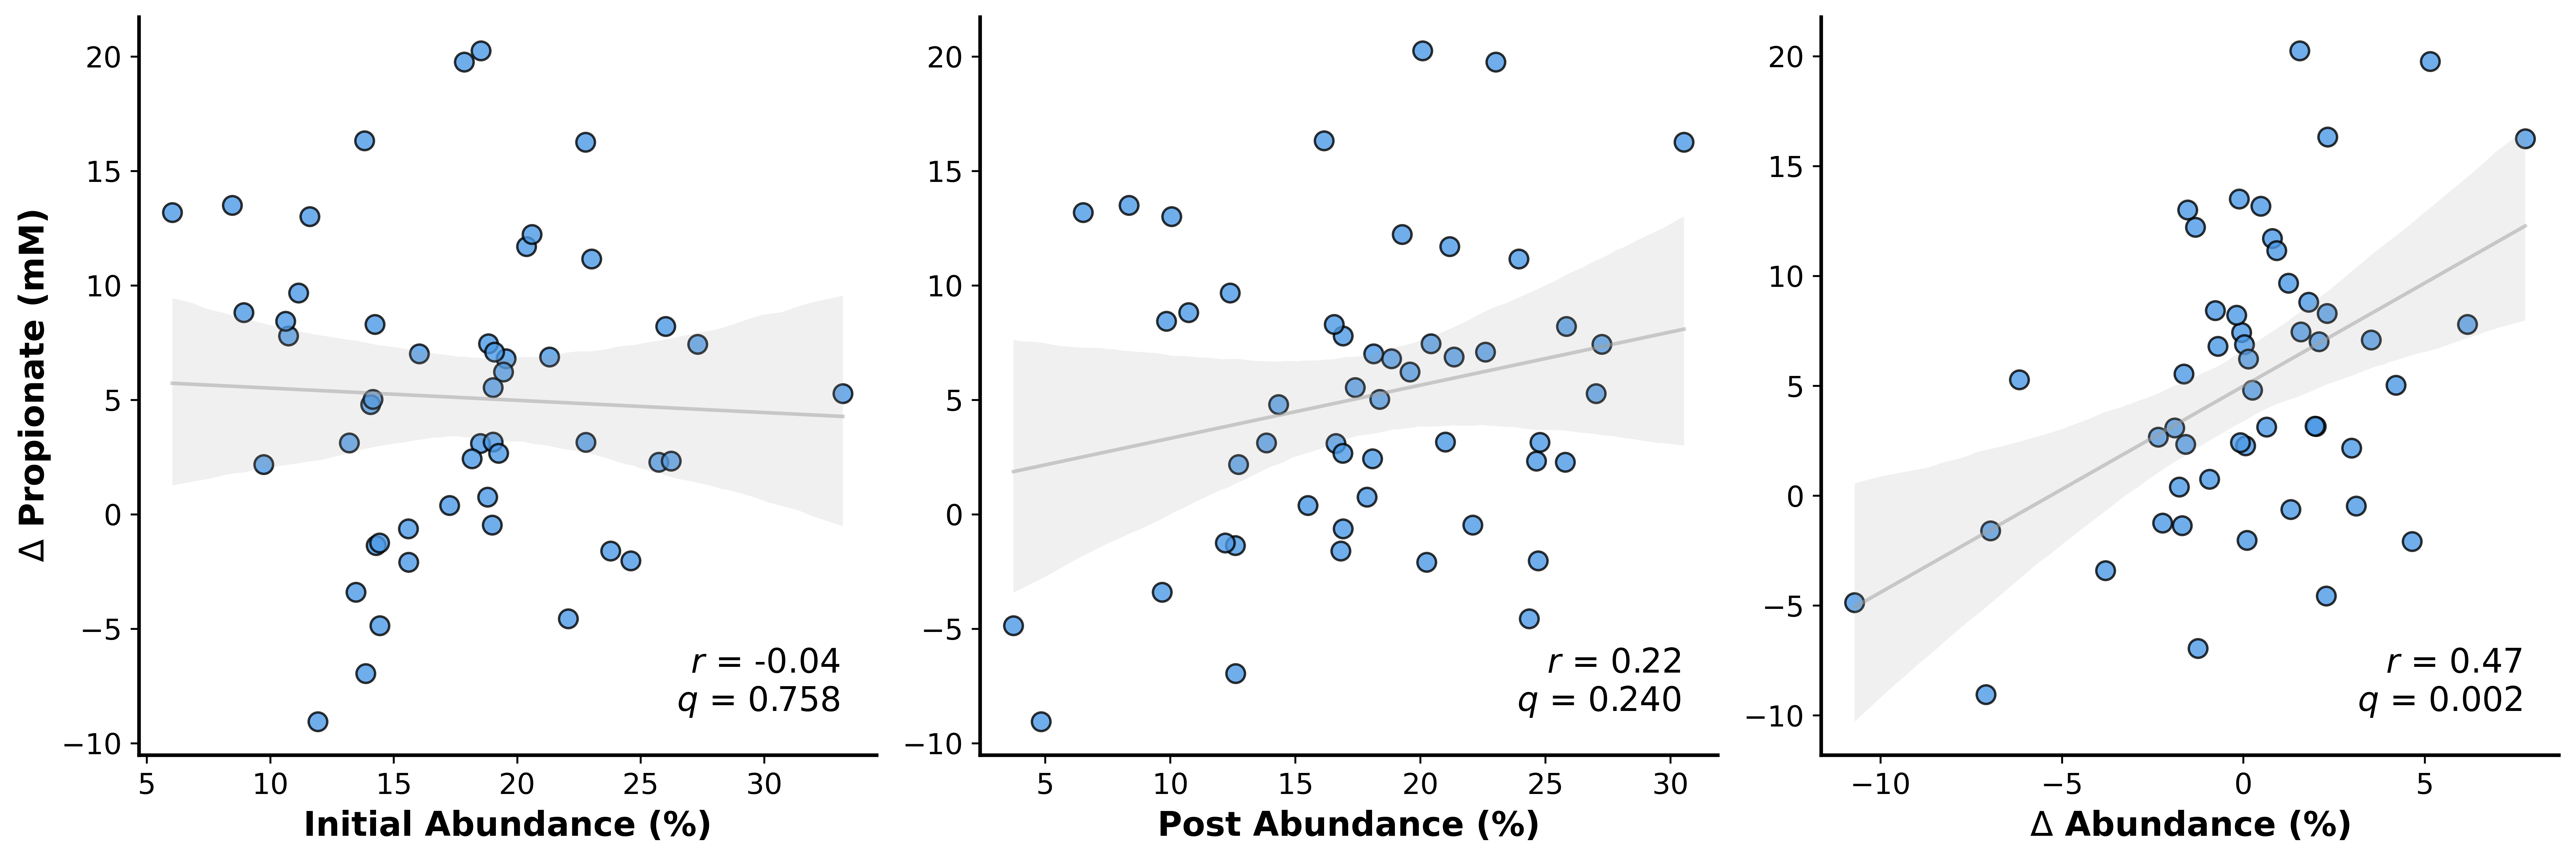

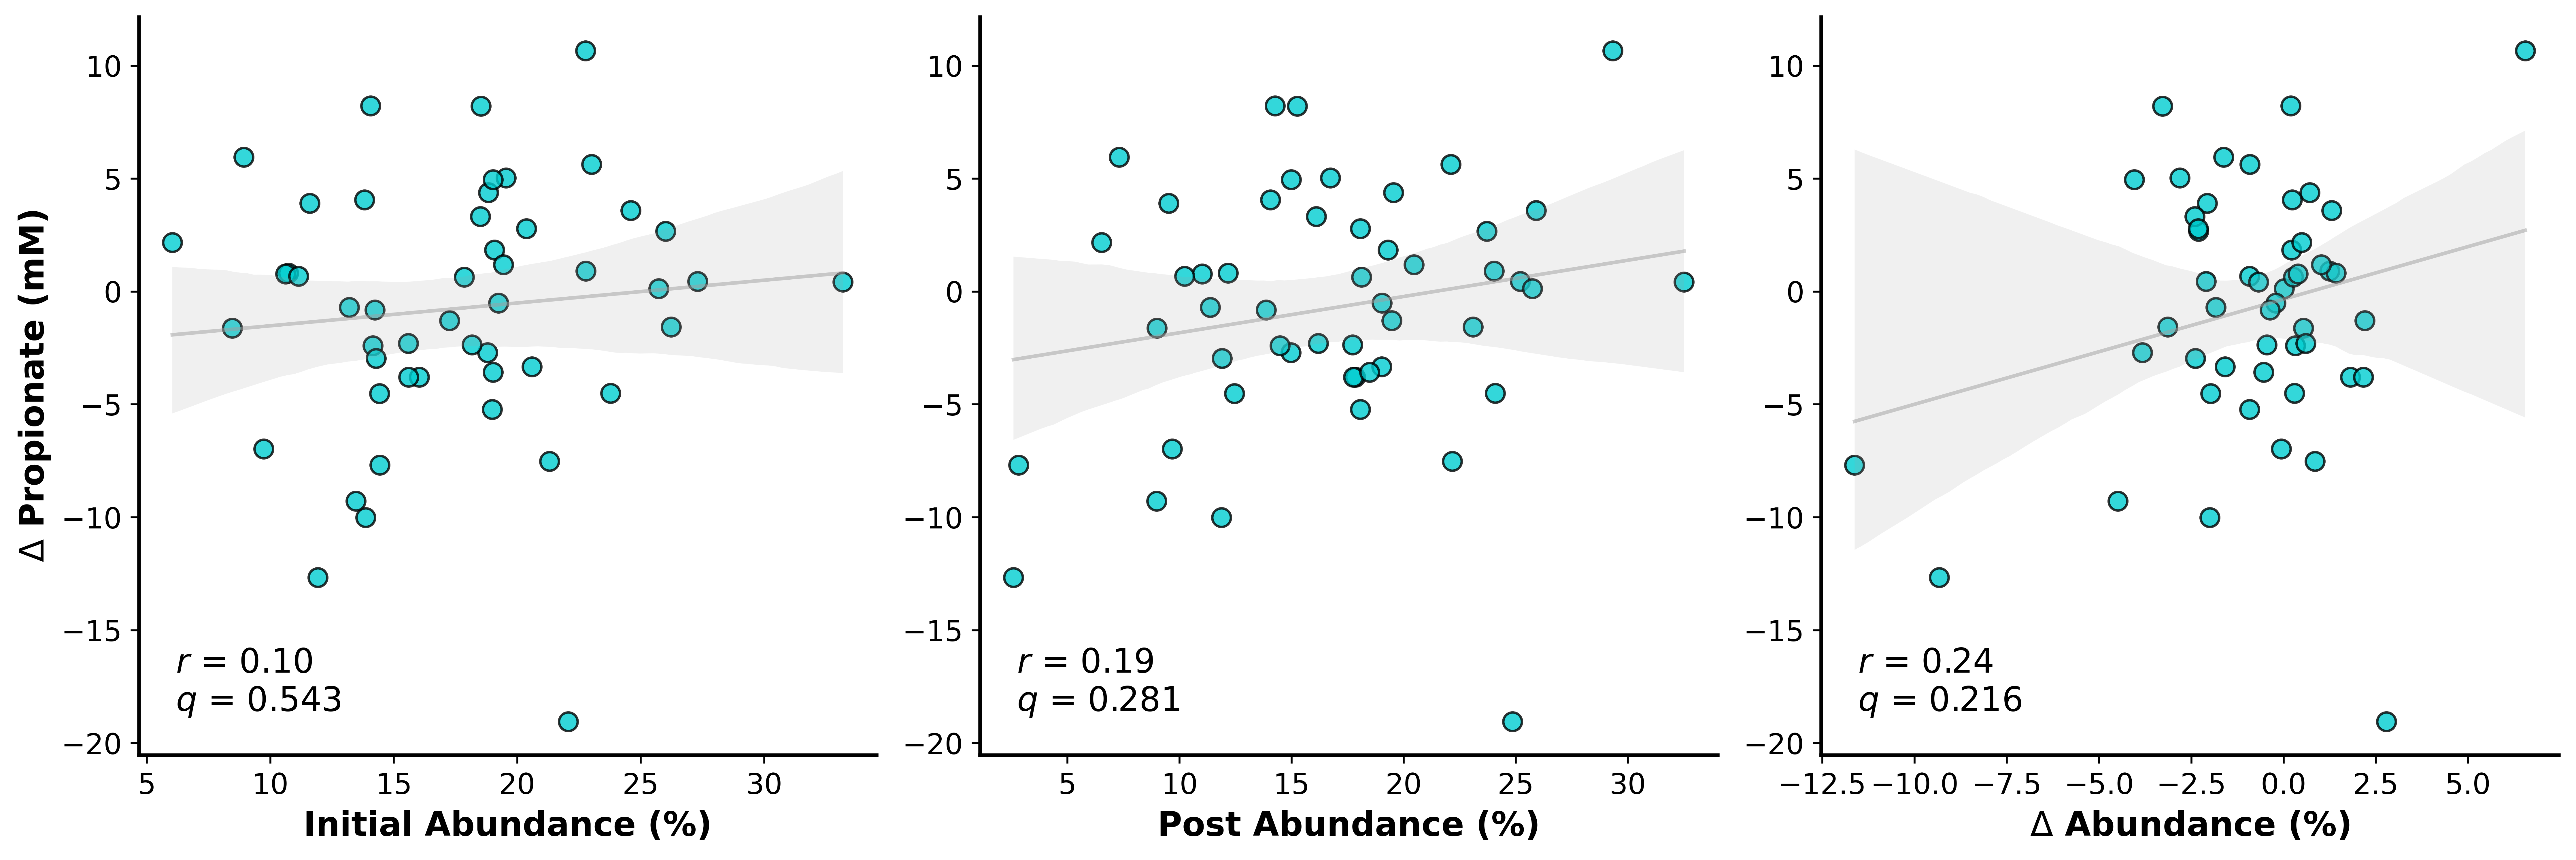

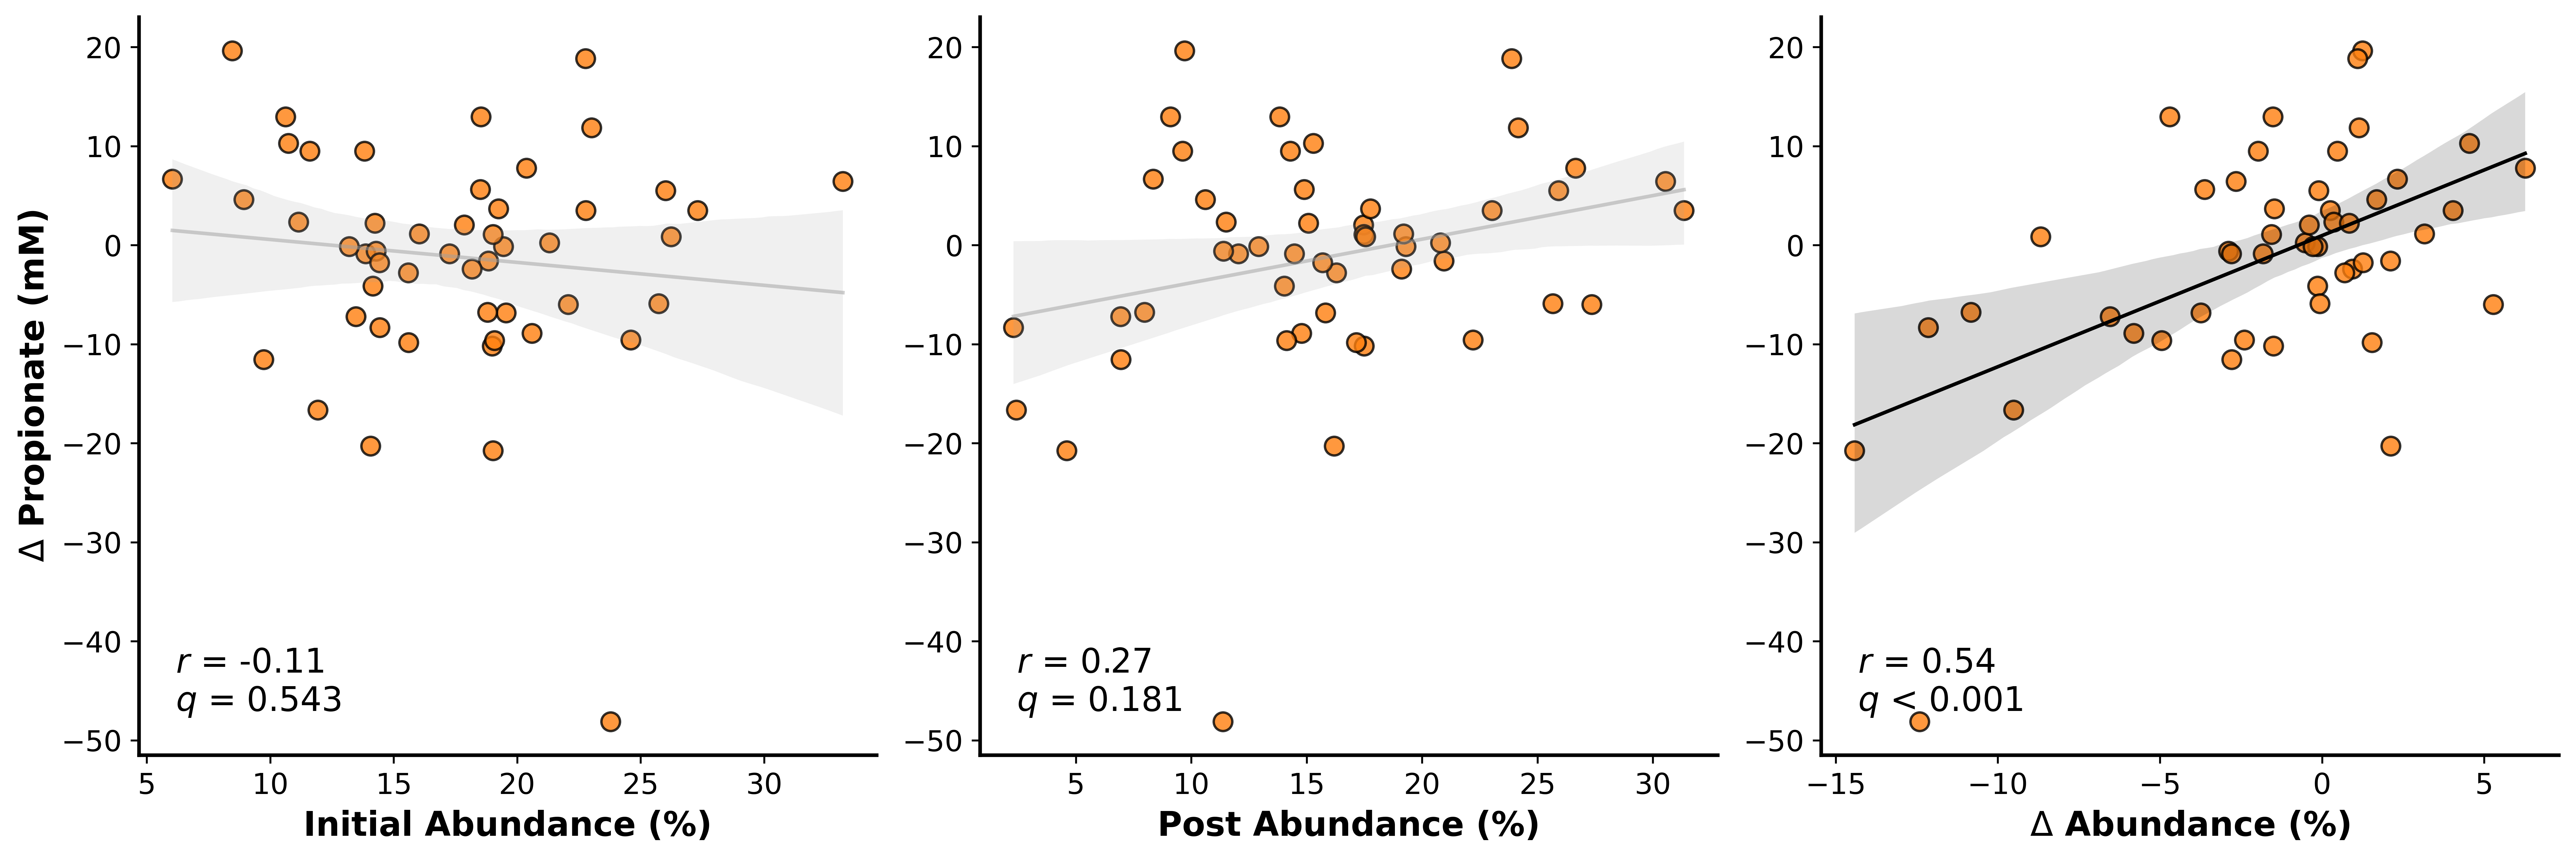

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
import statsmodels.stats.multitest as multitest
import warnings

warnings.filterwarnings('ignore')

# ==========================================
# 1. Global Page and Font Settings
# ==========================================
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['font.weight'] = 'normal'
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
DPI_SETTING = 600

def clean_and_convert_strict(vals):
    s_vals = pd.Series(vals).astype(str).replace(['Undetermined', '-', 'nan', 'NaN', '#VALUE!', ''], np.nan)
    return pd.to_numeric(s_vals, errors='coerce')

# ==========================================
# 2. Data Loading & Processing (16S & Propionate)
# ==========================================
# --- 16S Data (Relative Abundance %) ---
df_16s = pd.read_csv("(KULFFI)_16S_Genus_level.csv")
clusters = df_16s['Cluster'].unique()
feat_map = {'CUL': 'Control', 'Resistant maltodextrin': 'RMD', 'Resistant starch': 'RS', 'Mannose': 'Mannose'}
target_ingredients = ['Resistant maltodextrin', 'Resistant starch', 'Mannose']

bac_cols = [c for c in df_16s.columns if str(c).startswith('d__Bacteria')]
bact_taxa = 'd__Bacteria;p__Bacteroidota;c__Bacteroidia;o__Bacteroidales;f__Bacteroidaceae;g__Bacteroides'
bact_col = [c for c in df_16s.columns if bact_taxa in c][0]

donor_16s_data = {}
for cluster in clusters:
    df_cluster = df_16s[df_16s['Cluster'] == cluster]
    donor_id = cluster
    if donor_id not in donor_16s_data:
        donor_16s_data[donor_id] = {}

    for feat_raw, feat_mapped in feat_map.items():
        row = df_cluster[df_cluster['Feature'] == feat_raw]
        if not row.empty:
            bact_count = row[bact_col].values[0]
            total_count = row[bac_cols].sum(axis=1).values[0]
            rel_abund = (bact_count / total_count) * 100 if total_count > 0 else 0
            donor_16s_data[donor_id][feat_mapped] = rel_abund

# --- Propionate Data ---
df_prop = pd.read_csv('Propionate(mM).csv')
donor_cols = [c for c in df_prop.columns if c.startswith('HS-')]

ctrl_mask = df_prop.iloc[:, 2].astype(str).str.contains('Control', case=False, na=False)
if not ctrl_mask.any():
    ctrl_mask = df_prop.iloc[:, 0].astype(str).isin(['0', '000'])
ctrl_vals_prop = clean_and_convert_strict(df_prop.loc[ctrl_mask, donor_cols].iloc[0].values)
prop_ctrl_dict = dict(zip(donor_cols, ctrl_vals_prop))

prop_data = {}
for ingredient, mapped_name in zip(target_ingredients, ['RMD', 'RS', 'Mannose']):
    mask = df_prop.iloc[:, 2] == ingredient
    if not mask.any() and ingredient == 'Mannose':
        mask = df_prop.iloc[:, 2].str.contains('Mannose', case=False, na=False)
    if mask.any():
        treat_vals = clean_and_convert_strict(df_prop.loc[mask, donor_cols].iloc[0].values)
        prop_data[mapped_name] = dict(zip(donor_cols, treat_vals))

# ==========================================
# 3. Calculate FDR Corrected q-values
# ==========================================
ingredients_to_plot = [('RMD', '#4C99E6'), ('RS', '#00CED1'), ('Mannose', '#ff7f0e')]
letters = ['c', 'd', 'e']

all_p_values = []
plot_data_dict = {}

for ing_name, color in ingredients_to_plot:
    x_init, x_delta, x_post, y_delta = [], [], [], []

    for donor in donor_cols:
        if donor in donor_16s_data and 'Control' in donor_16s_data[donor] and ing_name in donor_16s_data[donor]:
            if donor in prop_data[ing_name] and not np.isnan(prop_data[ing_name][donor]) and not np.isnan(prop_ctrl_dict[donor]):
                bact_ctrl = donor_16s_data[donor]['Control']
                bact_treat = donor_16s_data[donor][ing_name]
                prop_ctrl = prop_ctrl_dict[donor]
                prop_treat = prop_data[ing_name][donor]

                x_init.append(bact_ctrl)
                x_delta.append(bact_treat - bact_ctrl)
                x_post.append(bact_treat)
                y_delta.append(prop_treat - prop_ctrl)

    if len(x_init) >= 5:
        plot_data_dict[ing_name] = {'x_init': x_init, 'x_delta': x_delta, 'x_post': x_post, 'y_delta': y_delta}
        # Order exactly matches the final plotting order: Initial, Post, Delta
        for x_data in [x_init, x_post, x_delta]:
            _, p = pearsonr(x_data, y_delta)
            all_p_values.append(p)

# Benjamini-Hochberg FDR Correction
_, q_values, _, _ = multitest.multipletests(all_p_values, alpha=0.05, method='fdr_bh')

# ==========================================
# 4. Figure Generation (S3c, S3d, S3e)
# ==========================================
q_index = 0
for (ing_name, color), letter in zip(ingredients_to_plot, letters):
    if ing_name not in plot_data_dict: continue
    data = plot_data_dict[ing_name]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=DPI_SETTING)
    plot_configs = [(axes[0], data['x_init'], 'Initial Abundance (%)'),
                    (axes[1], data['x_post'], 'Post Abundance (%)'),
                    (axes[2], data['x_delta'], r'$\Delta$ Abundance (%)')]

    for ax, x_data, xlabel in plot_configs:
        # Calculate Pearson's r BEFORE plotting to determine line styling
        r, _ = pearsonr(x_data, data['y_delta'])

        # Determine dynamic line styling based on correlation robustness (threshold: |r| > 0.5)
        if abs(r) > 0.5:
            line_color = 'black'
            line_alpha = 1.0
        else:
            line_color = '#A0A0A0'  # Lighter gray
            line_alpha = 0.5

        sns.regplot(x=x_data, y=data['y_delta'], ax=ax,
                    scatter_kws={'color': color, 'edgecolor': 'black', 's': 60, 'linewidths': 1},
                    line_kws={'color': line_color, 'alpha': line_alpha, 'linewidth': 1.5})

        q = q_values[q_index]
        q_index += 1

        # Determine annotation position based on substrate
        if ing_name == 'RMD':
            text_x, text_y = 0.95, 0.05
            text_ha = 'right'
        else:
            text_x, text_y = 0.05, 0.05
            text_ha = 'left'

        q_str = "< 0.001" if q < 0.001 else f"= {q:.3f}"

        # Apply annotation (fontweight strictly 'normal')
        ax.text(text_x, text_y, f"$r$ = {r:.2f}\n$q$ {q_str}",
                transform=ax.transAxes, ha=text_ha, va='bottom', fontsize=14, fontweight='normal')

        ax.set_xlabel(xlabel, fontsize=14, fontweight='bold')
        if ax == axes[0]:
            ax.set_ylabel(r'$\Delta$ Propionate (mM)', fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel('')

        ax.tick_params(axis='both', which='major', labelsize=12)
        for s in ['top', 'right']: ax.spines[s].set_visible(False)
        for s in ['left', 'bottom']: ax.spines[s].set_linewidth(1.5)
        ax.set_box_aspect(1)

    plt.tight_layout()
    output_filename = f"Supplementary_Figure_S3{letter}_{ing_name}.pdf"
    plt.savefig(output_filename, dpi=DPI_SETTING, bbox_inches='tight', transparent=True)
    plt.show()